#### Implementing KNN Classifiers with Scikit-Learn

In [23]:
import sys
!{sys.executable} -m pip install pandas
!{sys.executable} -m pip install scikit-learn
!{sys.executable} -m pip install matplotlib


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ------ --------------------------------- 1.3/8.1 MB 9.5 MB/s eta 0:00:01
   ---------------- ----------------------- 3.4/8.1 MB 9.1 MB/s eta 0:00:01
   --------------------------- ------------ 5.5/8.1 MB 9.3 MB/s eta 0:00:01
   ------------------------------------- -- 7.6/8.1 MB 9.6 MB/s eta 0:00:01
   ---------------------------------------  8.1/8.1 MB 8.7 MB/s eta 0:00:01
   ---------------------------------------- 8.1/8.1 MB 6.9 MB/s  0:00:01
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ------------------------------- -------- 1.8/2.3 MB 9.2 MB/s eta 0:00:01
   ---------------------------------------- 2.3/2.3 MB 7.0 MB/s  0:00:00
   ---------------------------------------- 0.0/7.0 MB ? eta -:--:--
   ----------- ---------------------------- 2.1/7.0 MB 11.8 MB/s eta 0:00:01
   ------------------- -------------------- 3.4/7.0 MB 10.1 MB/s eta 0:00:01
   -------------------------- -------


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler # we'll see why this is important
import pandas as pd
import numpy as np


import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


In [3]:
data = load_iris()
X = data.data          # data refers to the attributes or better yet *features* of the flowers
y = data.target        # target refers to the discrete classes

In [4]:
df = pd.DataFrame(data.data, columns=data.feature_names)
df['species'] = data.target

print(df.head())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   species  
0        0  
1        0  
2        0  
3        0  
4        0  


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y)

In [6]:
clf = KNeighborsClassifier(n_neighbors=5)

In [7]:
clf.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [8]:
y_pred = clf.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy}')

Accuracy: 0.9777777777777777


In [41]:
# Instantiate the scaler
scaler = StandardScaler()

# Fit the scaler on the training data and transform both training and test data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test) # Use transform, not fit_transform, on test data!

# Instantiate a new KNN classifier
knn_scaled = KNeighborsClassifier(n_neighbors=15)

# Train on the scaled data
knn_scaled.fit(X_train_scaled, y_train)

# Predict on the scaled test data
y_pred_scaled = knn_scaled.predict(X_test_scaled)

# Evaluate the scaled model
accuracy_scaled = accuracy_score(y_test, y_pred_scaled)
print(f"Scaled Model Accuracy: {accuracy_scaled:.4f}")

Scaled Model Accuracy: 0.9333


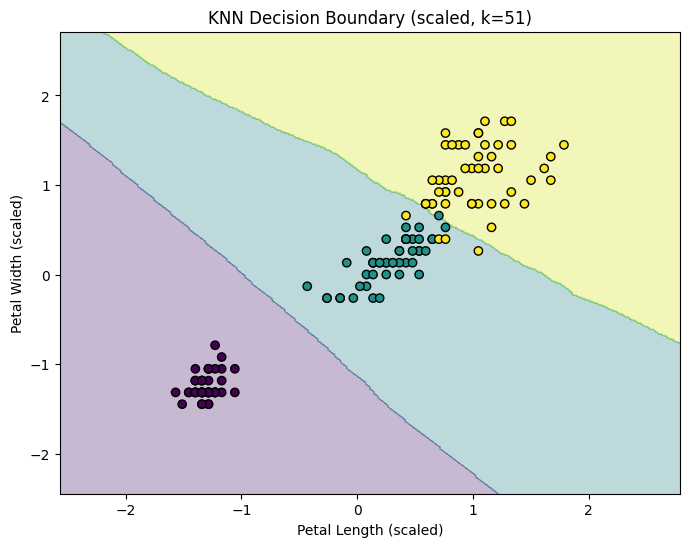

In [49]:
#2D Knn example

# Load data
iris = load_iris()
X = iris.data[:, [2, 3]]  # Petal length, petal width
y = iris.target

# Scale using one scaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Fit KNN on ALL data for plotting
knn_plot = KNeighborsClassifier(n_neighbors=51)
knn_plot.fit(X_scaled, y)

# Create mesh grid
x_min, x_max = X_scaled[:,0].min() - 1, X_scaled[:,0].max() + 1
y_min, y_max = X_scaled[:,1].min() - 1, X_scaled[:,1].max() + 1
xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

# Predict grid labels
Z = knn_plot.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot the decision boundary
plt.figure(figsize=(8,6))
plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=y, edgecolor="k")

plt.xlabel("Petal Length (scaled)")
plt.ylabel("Petal Width (scaled)")
plt.title("KNN Decision Boundary (scaled, k=51)")
plt.show()

In [42]:

new_data = [([6.7, 2.1, 4.1, 2.2])]
pred_cat = knn_scaled.predict(new_data)

print(pred_cat)

print(data.target_names)

[2]
['setosa' 'versicolor' 'virginica']


In [43]:
new_data = [([0.1, 0.4, 0.8, 1.2])]
pred_cat = knn_scaled.predict(new_data)

print(pred_cat)

[2]


In [44]:
new_data = [([0.1, 0.4, 0.8, 1.2])]
pred_cat = knn_scaled.predict(new_data)

print(pred_cat)

[2]


In [45]:
new_data = [([0.1, 0.4, 0.8, 0.6])]
pred_cat = knn_scaled.predict(new_data)

print(pred_cat)

[1]
